-# ODWFS Intensity Analysis
Last edited: 08-05-26

This notebook measures the integrated intensity in the left and right ODWFS pupils while scanning in the x- and y-directions. It uses the functions contained in `intensity.py` to load images, verify the pupil locations, perform aperture photometry, and visualize the results.

for the B-series and T-series datasets collected with the ThorLabs CS165MU Zelux® 1.6 MP Monochrome CMOS Camera.

**Analysis steps:**
1. Load camera images
2. Determine the pupil locations
3. Measure integrated intensities of each pupul
4. Plot intensity vs. focal mirror voltage

## 0. Imports
Import the analysis functions contained in `intensity.py`. Automatic reloading is enabled so any changes made to the script are immediately reflected in the notebook without restarting the kernel.

In [1]:
# Script
import odwfs as od 

%load_ext autoreload
%autoreload 2

## 1. Load Camera Images
All camera images are stored in a single experiment directory. The filenames contain the series (B or T), the scan direction (x or y), the x- and y-voltages, and the acquisition timestamp. Images are automatically parsed by `load_series()`.

Each image filename in the directory must follow the naming convention:

`<Series>_series_<Measurement>_X<Voltage>_Y<Voltage>_<Timestamp>.tif`

where
- `B_series` or `T_series` = identifies the image series (`B` or `T`)
   - Do not include for `init` images.
- `init`, `x` or `y` = identifies the measurement type:
   - `init` = initial reference image
   - `x` = x-scan (x fixed, y varied)
   - `y` = y-scan (x varied, y fixed)
- `Xn1d070` = x-axis voltage. The first letter indicates the axis (`X`), `n` indicates a negative voltage (`p` indicates positive), and `d` represents the decimal point. For example:
   - `Xn1d070` $\implies$ **-1.07 V**
   - `Xp0d250` $\implies$ **+0.250 V**
- `Yp0d176` = y-axis voltage using the same convention:
   - `Xn1d070` $\implies$ **+0.176 V**
   - `Yn0d050` $\implies$ **−0.050 V**
- `_2026-07-30T13-46-23.947.tif` = acquisition timestamp in the format `YYYY-MM-DDTHH-MM-SS.sss`.

For example,

```text
B_series_x_Xn1d070_Yp0d176_2026-07-30T13-46-23.947.tif

In [2]:
# directory = "data/2026-07-30_exp01"
directory = "data/2026-08-05"

init_file, available = od.inspect_dataset(directory)

Initialization image: init_Xn1d221_Yp0d153_2026-08-05T11-36-15.633.tif

Available scan series:
  B: none
  T: none


Initialization image: init_Xn1d221_Yp0d153_2026-08-05T11-36-15.633.tif
Voltages: X = -1.221 V, Y = 0.153 V


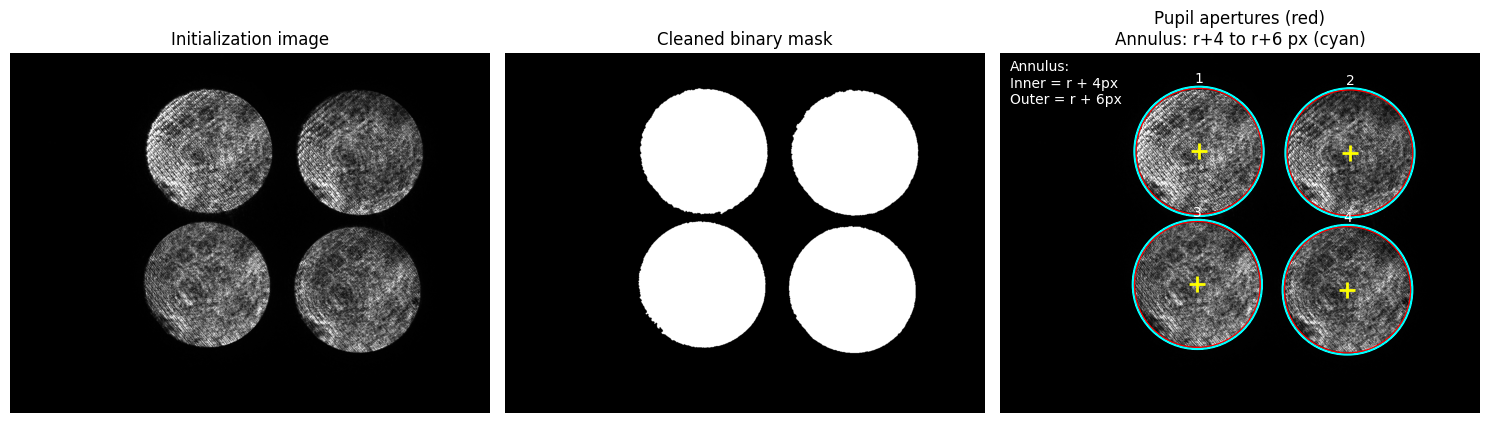

Found 4 pupils:
  Pupil 1: center=(596.6, 784.4), radius=189.1
  Pupil 2: center=(1049.4, 780.0), radius=188.8
  Pupil 3: center=(591.5, 385.3), radius=188.9
  Pupil 4: center=(1041.9, 369.2), radius=189.7


In [35]:
init = od.find_init_pupils(
    init_file,
    annulus_inner_offset=4,
    annulus_outer_offset=6,
)

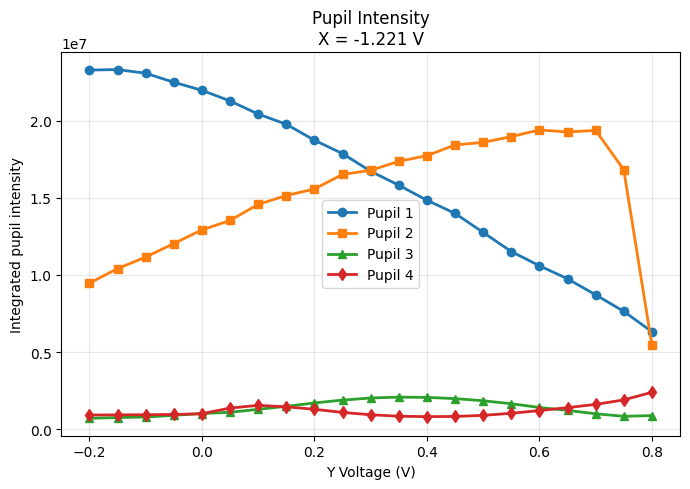

In [36]:
voltage, flux, fixed_voltage = od.measure_series(
    directory,
    "x",
    init["pupils"],
    flux_function=od.pupil_flux,
)

od.plot_intensity(
    "x",
    voltage,
    flux,
    fixed_voltage,
    ylabel="Integrated pupil intensity",
    title_prefix="Pupil",
)

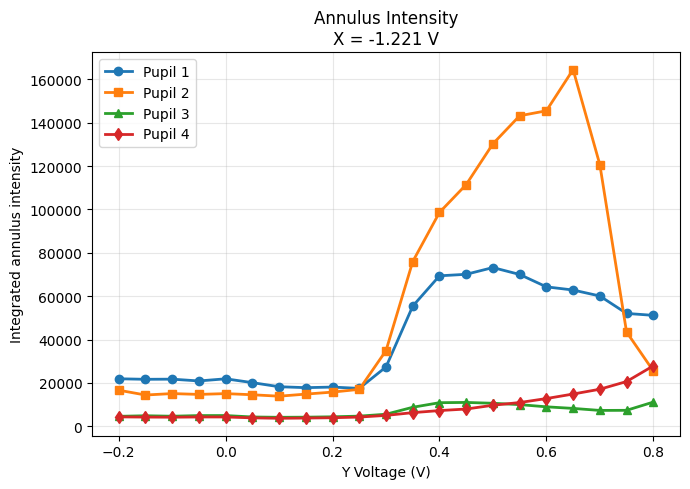

In [37]:
voltage, annulus_flux, fixed_voltage = od.measure_series(
    directory,
    "x",
    init["pupils"],
    flux_function=od.annulus_flux,
)

od.plot_intensity(
    "x",
    voltage,
    annulus_flux,
    fixed_voltage,
    ylabel="Integrated annulus intensity",
    title_prefix="Annulus",
)

/scr2/bpeck/work/odwfs/odwfs.py:777: RuntimeWarning: overflow encountered in scalar subtract
/scr2/bpeck/work/odwfs/odwfs.py:783: RuntimeWarning: overflow encountered in scalar subtract


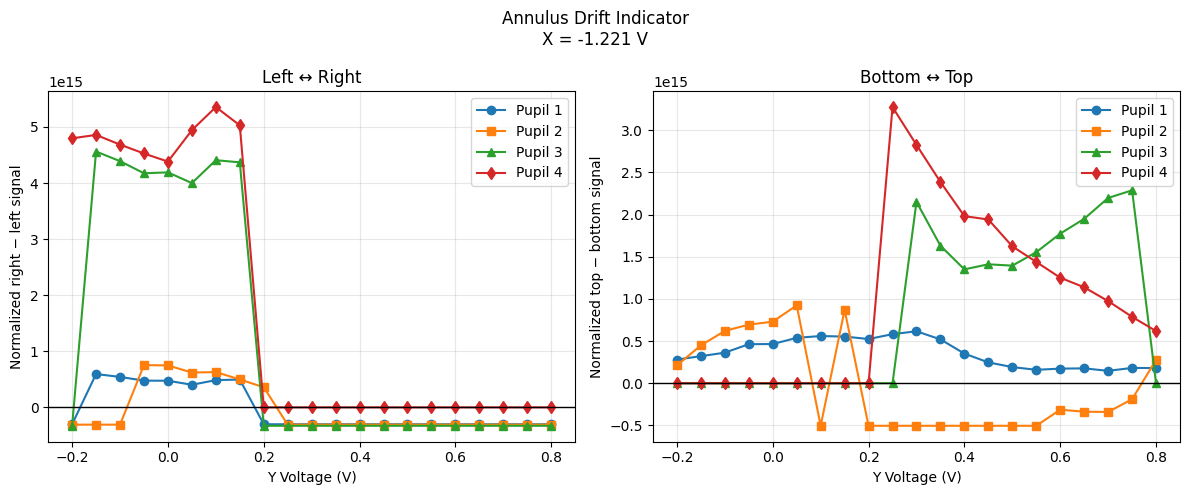

In [26]:
voltage, horizontal, vertical, fixed_voltage = (
    od.measure_annulus_drift(
        directory,
        "x",
        init,
    )
)

od.plot_annulus_drift(
    "x",
    voltage,
    horizontal,
    vertical,
    fixed_voltage,
)